# Bring the metrics from different experiments at one place for comparison

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

from scipy.stats import rankdata, wilcoxon

In [2]:
# freezing detector: exp22 vs exp23
# objW1: exp10 vs exp19
# objW2: exp10 vs exp22, exp19 vs exp22
# larger MHA: exp24 vs exp27, exp23 vs exp25
# dino: exp10 vs expD1, exp10 vs expD2

In [3]:
def plot_averages_by_k2(averages, exclude_groups=[]):
    # Extract unique keys
    groups = sorted({k2 for v in averages.values() for k2 in v})  # k2
    groups = [i for i in groups if i not in exclude_groups]
    subgroups = list(averages.keys())  # k1
    
    # Prepare data
    data = []
    for k2 in groups:
        row = [averages[k1].get(k2, 0) for k1 in subgroups]  # fill missing with 0
        data.append(row)
    
    data = np.array(data)
    
    # Bar chart setup
    x = np.arange(len(groups))  # positions for groups (k2)
    bar_width = 0.8 / len(subgroups)
    
    fig, ax = plt.subplots(figsize=(30, 15))
    
    # Plot each subgroup (k1)
    for i, k1 in enumerate(subgroups):
        bars = ax.bar(x + i*bar_width, data[:, i], width=bar_width, label=k1)
        
        # Add labels with 3 decimal places
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10, rotation=90)
    
    # Styling
    ax.set_xticks(x + bar_width*(len(subgroups)-1)/2)
    ax.set_xticklabels(groups, rotation=90)
    ax.legend(title="Legend")


In [4]:
def get_ranks(data, metricsnames, top_n=3, excluded_objects=[], return_full=False, exclude_experiments=[]):
    # top_n = 3
    for metricname in metricsnames:

        metric_data = {k: {k1: v1 for k1, v1 in v.items() if k1 not in excluded_objects} for k, v in data[metricname].items()}
        metric_data = {k:v for k, v in metric_data.items() if k not in exclude_experiments}

        # Convert dict → DataFrame (rows = experiments, cols = datasets)
        df = pd.DataFrame(metric_data).T

        # --- 1. Ranking aggregation ---
        # Rank within each dataset (higher is better → so we rank -score)
        ranks = df.apply(lambda col: rankdata(-col), axis=0)
        avg_ranks = ranks.mean(axis=1)

        rank_results = pd.DataFrame({
            "Average Rank": avg_ranks,
            "Mean Performance": df.mean(axis=1)
        }).sort_values("Average Rank")
        
        print(f"=== Ranking Results for {metricname} ===")
        if return_full:
            print(rank_results.iloc[:top_n])
        else:
            print(rank_results.iloc[:top_n].index.tolist())

        print("\n")

In [5]:
# data = {}
# metricname = 'bleu'
# for expname in tqdm(exp_name_to_path.keys()):
#     exp_path = os.path.join(exp_dir, exp_name_to_path[expname])
#     exp_files = {int(i.split("_E")[-1][:-4]):i for i in os.listdir(exp_path) if i.endswith("csv") and "RAG_object_txt_metric_E" in i}
#     epoch = max(exp_files.keys())
#     print(expname, epoch)
#     filename = os.path.join(exp_path, exp_files[epoch])
#     df = pd.read_csv(filename)
#     df.rename(columns={"Unnamed: 0": "metric"}, inplace=True)
#     df.set_index('metric', inplace=True)
# #     data[f'{expname}_E{epoch}'] = df.loc[metricname].to_dict()

# # plot_averages_by_k2(data)
# # plt.title(f"{metricname} Metric")

In [6]:
metrics_list = [
    'accuracy',
    'meteor',
    # 'bleu',
    'bertscore',
    'rouge1',
    # 'rouge2',
    'rougeL',
    'radgraph_simple',
    # 'radgraph_partial',
    # 'radgraph_complete',
    'srr_bert_weighted_f1',
    # 'srr_bert_weighted_precision',
    # 'srr_bert_weighted_recall',
    # 'chexbert-5_micro avg_f1-score',
    'chexbert-all_micro avg_f1-score',
    # 'chexbert-5_macro avg_f1-score',
    # 'chexbert-all_macro avg_f1-score',
    # 'chexbert-5_weighted_f1',
    # 'chexbert-all_weighted_f1',
    # 'ratescore',
    # 'temporal_f1',
]

In [11]:
db_path = "/path/to/data/experiments/RAG/DB/impressionv2/text_db_test.json"
with open(db_path) as f:
    db = json.load(f)

for n in [2, 5, 10, 15, 20]:
    excluded_objects = [k for k, v in db.items() if len(v) < n]
    print(n, len(excluded_objects))

thresh = 150
excluded_objects = [k for k, v in db.items() if len(v) < thresh]
print(thresh, len(excluded_objects))

2 10
5 11
10 15
15 17
20 21
150 31


In [12]:
all_exp_name_to_path = {
    # "S1E19":"apm_klloss1_objW1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1DE1":"apm_dino_klloss1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1DE2":"apm_dino_vits_klloss1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1DE3":"apm_dino_vits_klloss1_objW1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    # "S1DE4": "apm_dino_vits_klloss1bidirect_MHAL_allTextfrozen_impressionv2_pdim_16_temp_0.01",
   
    "S1E10":"apm_klloss1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    # "S1E12": "klloss1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E19": "apm_klloss1_objW1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E22": "apm_klloss1_objW2bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E23": "apm_frozenDet_klloss1_objW2bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E24": "apm_frozenDet_weighted-klloss1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E25":'apm_frozenDet_klloss1_objW2bidirect_MHAL_allTextfrozen_impressionv2_pdim_16_temp_0.01',
    "S1E26":"apm_frozenDet_klloss1bidirect_MHAL_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E27": "apm_frozenDet_weighted-klloss1bidirect_MHAL_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E28": "apm_klloss1bidirect_MHAL_allTextfrozen_impressionv2_pdim_16_temp_0.01",
    "S1E30": "apm_klloss1bidirect_MHAL_allTextfrozen_impressionv2_pdim_128_temp_0.01",
}


In [13]:
# exp_name_to_path = {k: all_exp_name_to_path[k] for k in ['S1E22', 'S1E23']}
# exp_name_to_path = {k: all_exp_name_to_path[k] for k in ['S1E10', 'S1E19']} # for ObjW1
# exp_name_to_path = {k: all_exp_name_to_path[k] for k in ['S1E10', 'S1E22', "S1E19"]} # for ObjW2
# exp_name_to_path = {k: all_exp_name_to_path[k] for k in ["S1E23", 'S1E24', "S1E25","S1E27"]} # for Larger MHA
# exp_name_to_path = {k: all_exp_name_to_path[k] for k in ['S1E24', "S1E25"]} # for Larger MHA
# exp_name_to_path = {k: all_exp_name_to_path[k] for k in ['S1DE1', "S1DE2", "S1E10"]} # for Larger MHA
exp_name_to_path = {k: all_exp_name_to_path[k] for k in ['S1E10', "S1E30"]} # for Larger MHA
exp_dir = "/path/to/data/experiments/apm"

100%|██████████| 2/2 [00:00<00:00, 172.73it/s]


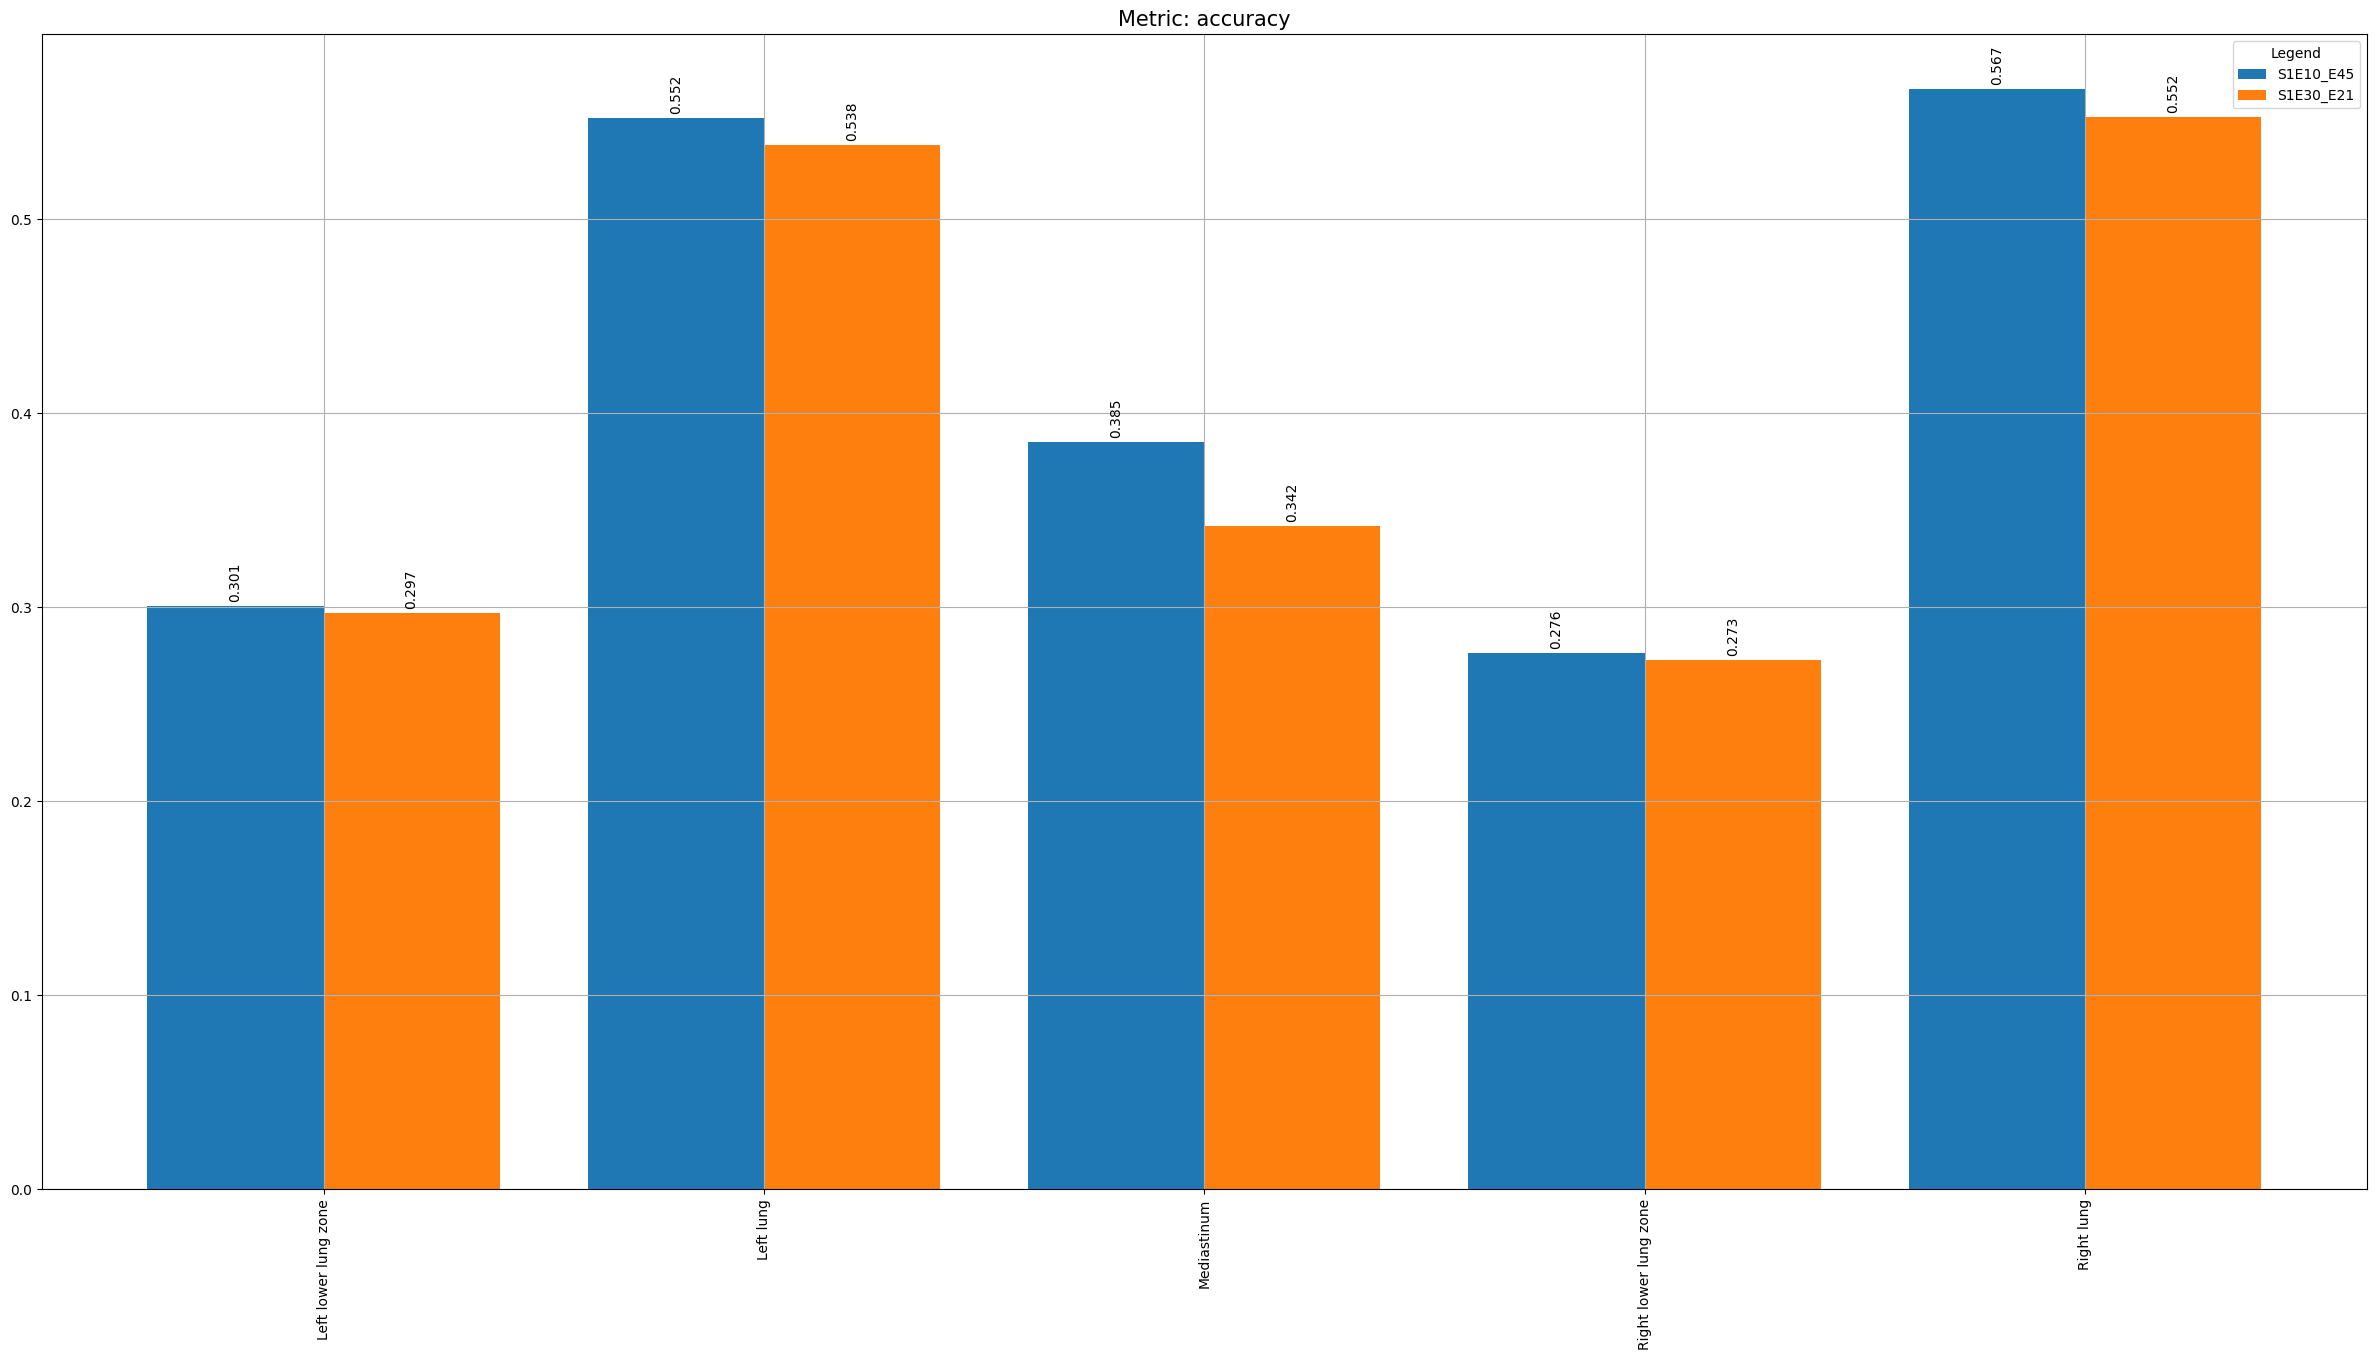

100%|██████████| 2/2 [00:00<00:00, 457.00it/s]


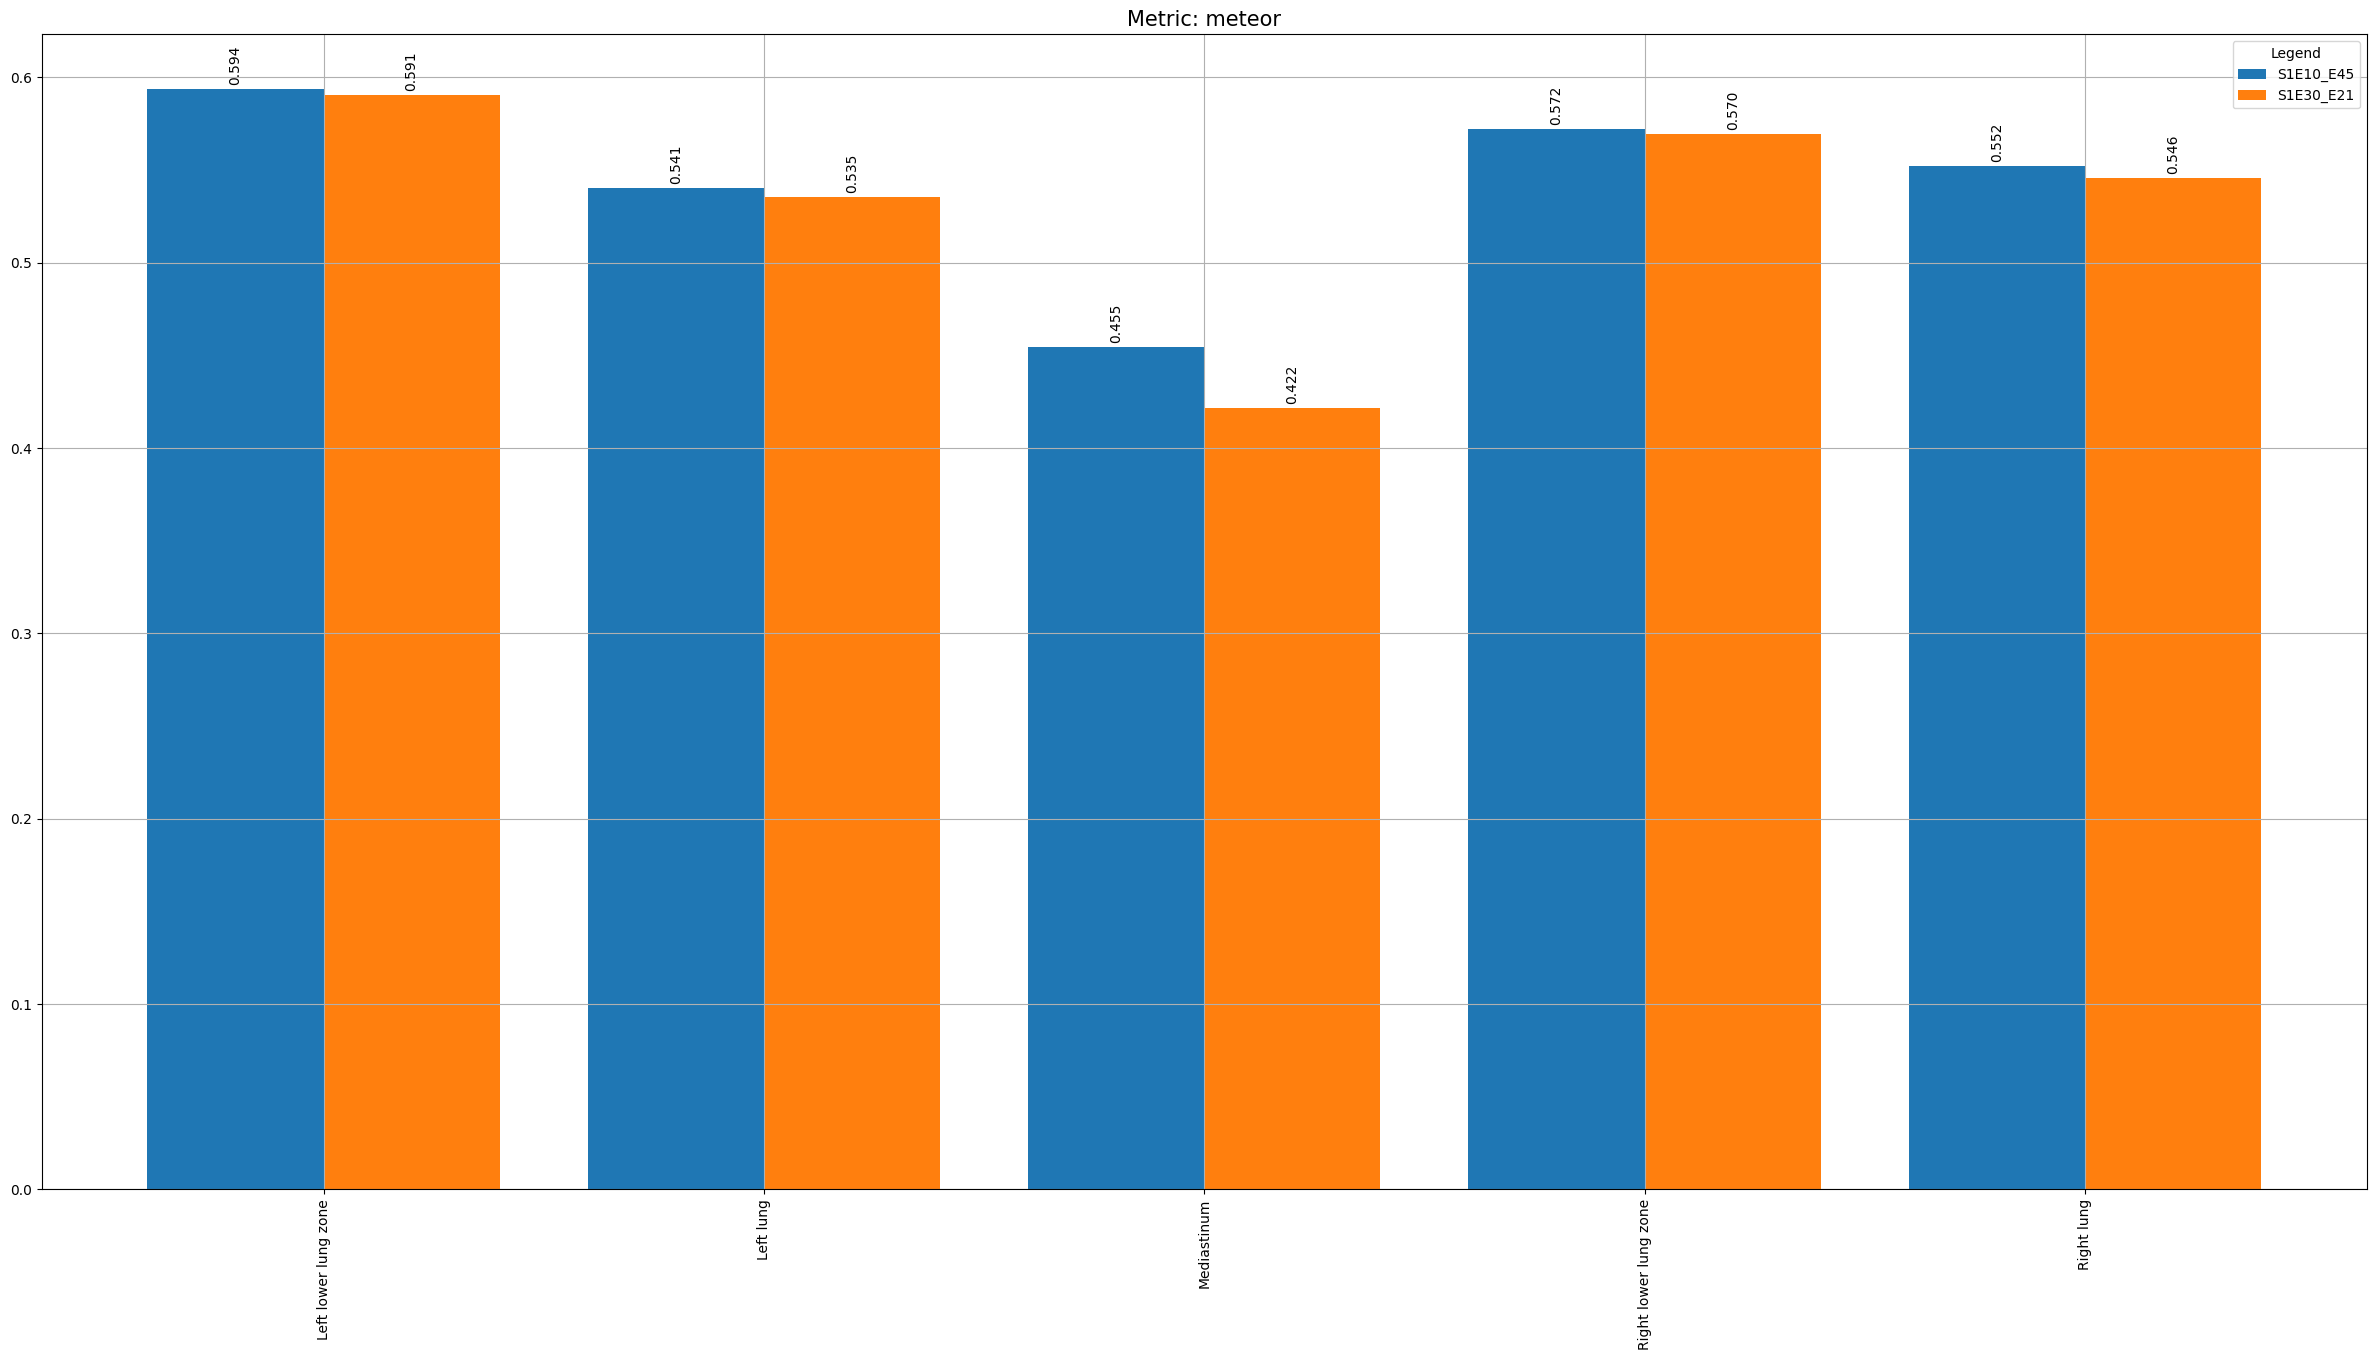

100%|██████████| 2/2 [00:00<00:00, 454.15it/s]


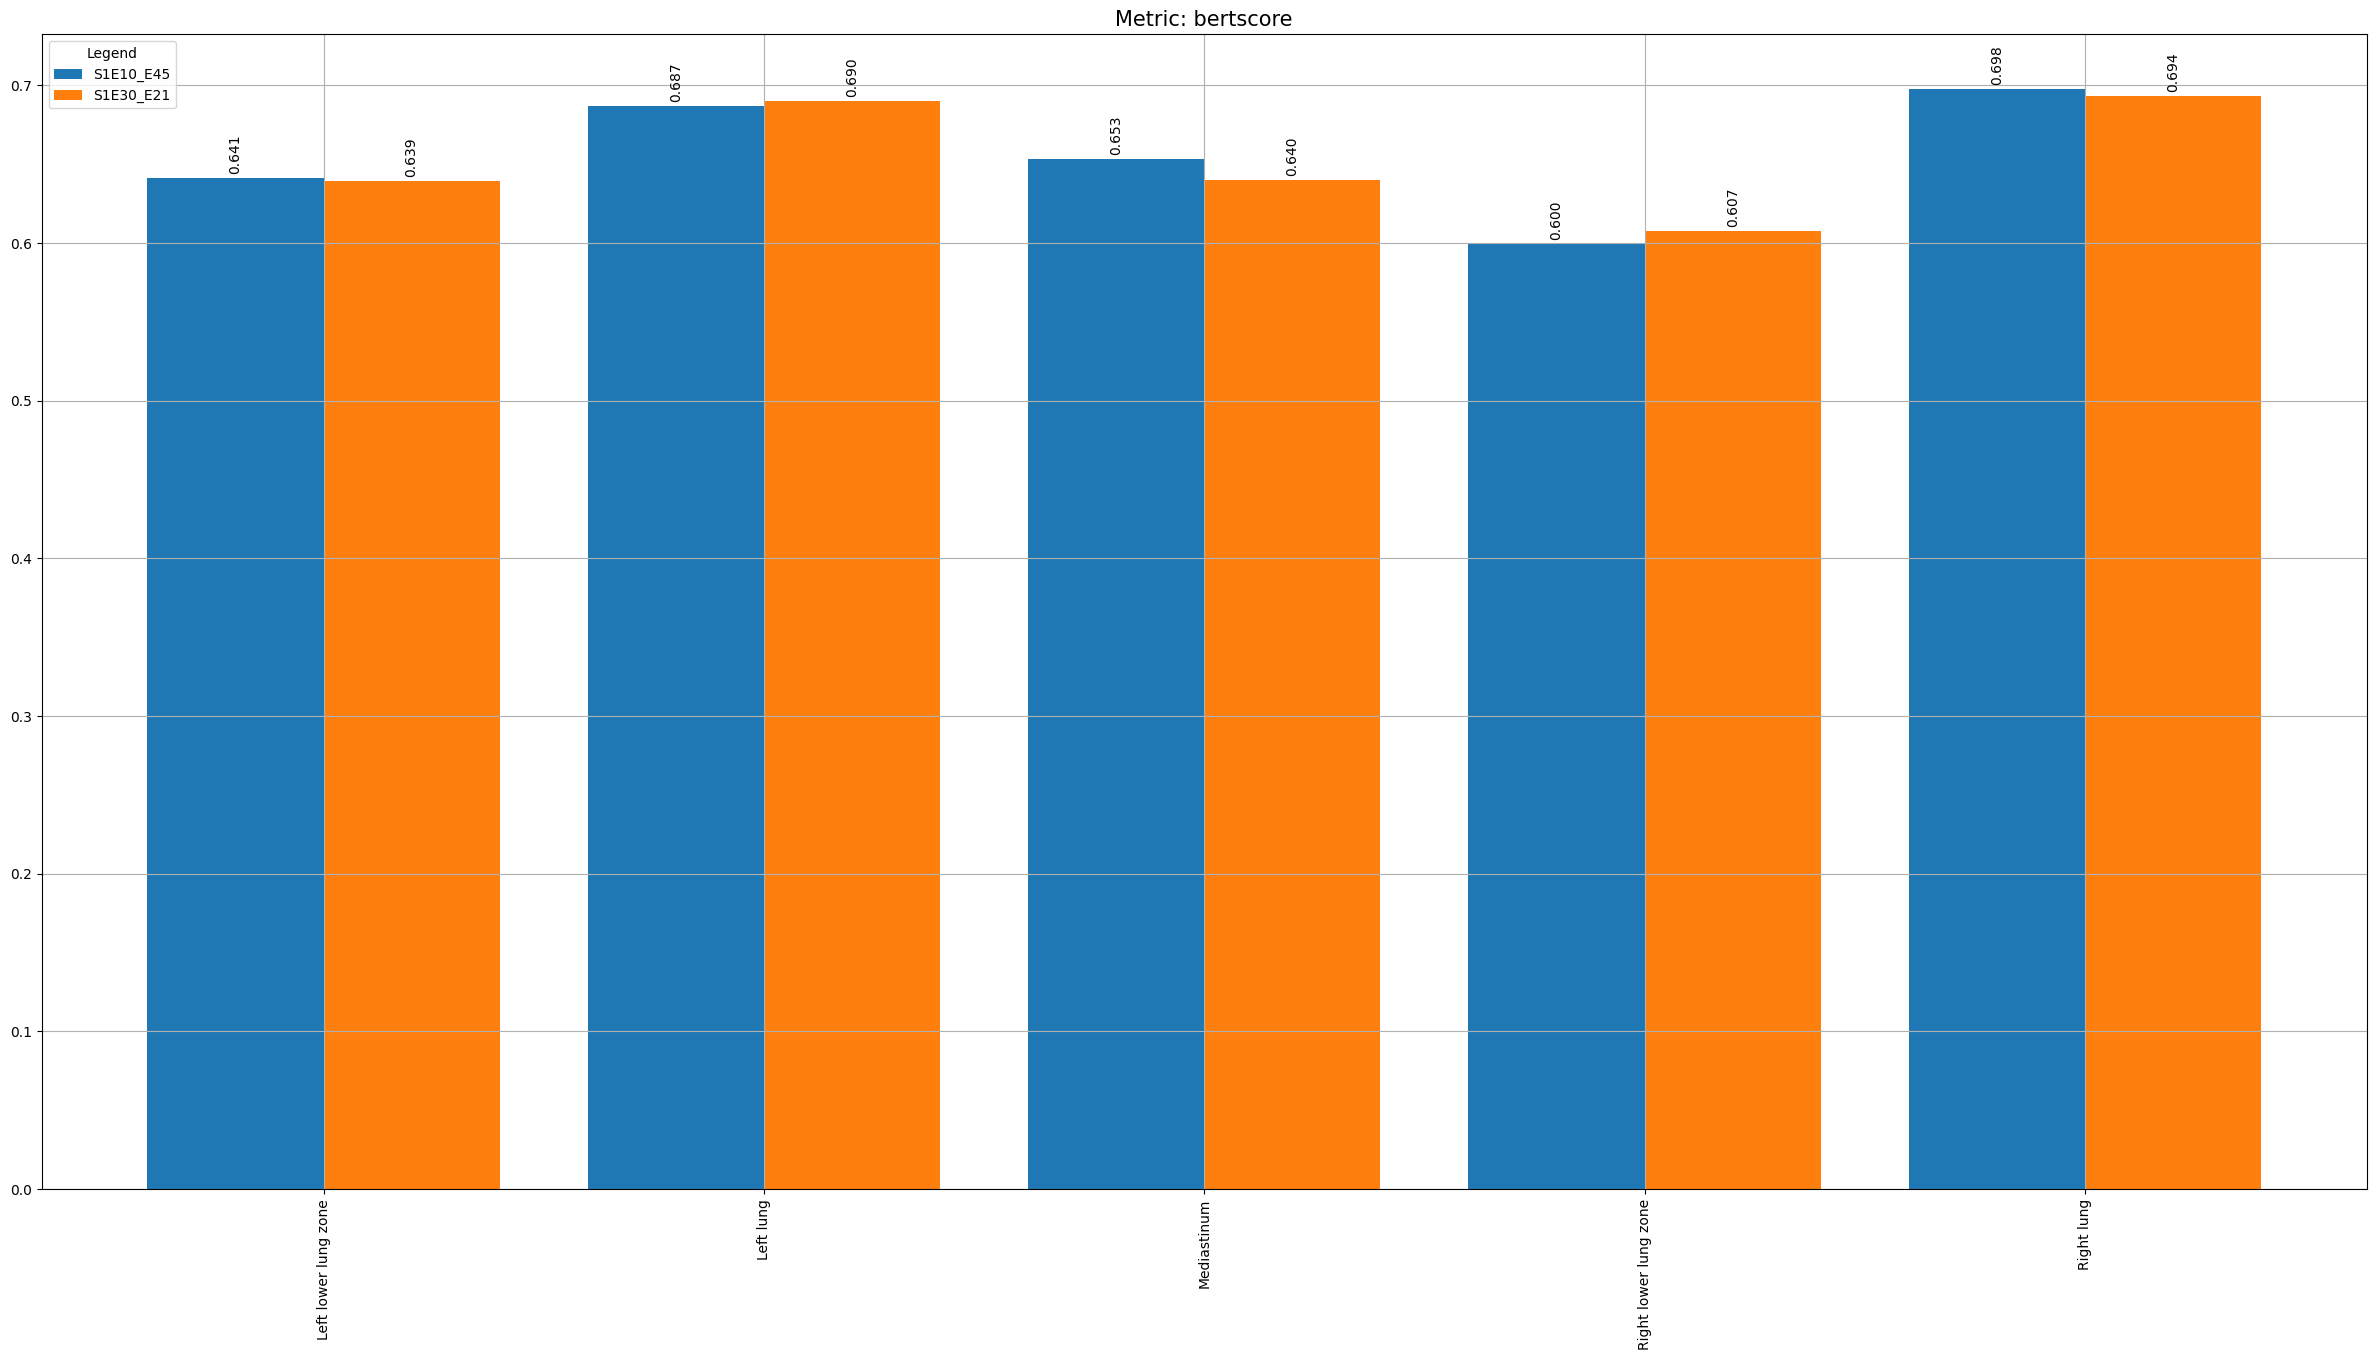

100%|██████████| 2/2 [00:00<00:00, 414.07it/s]


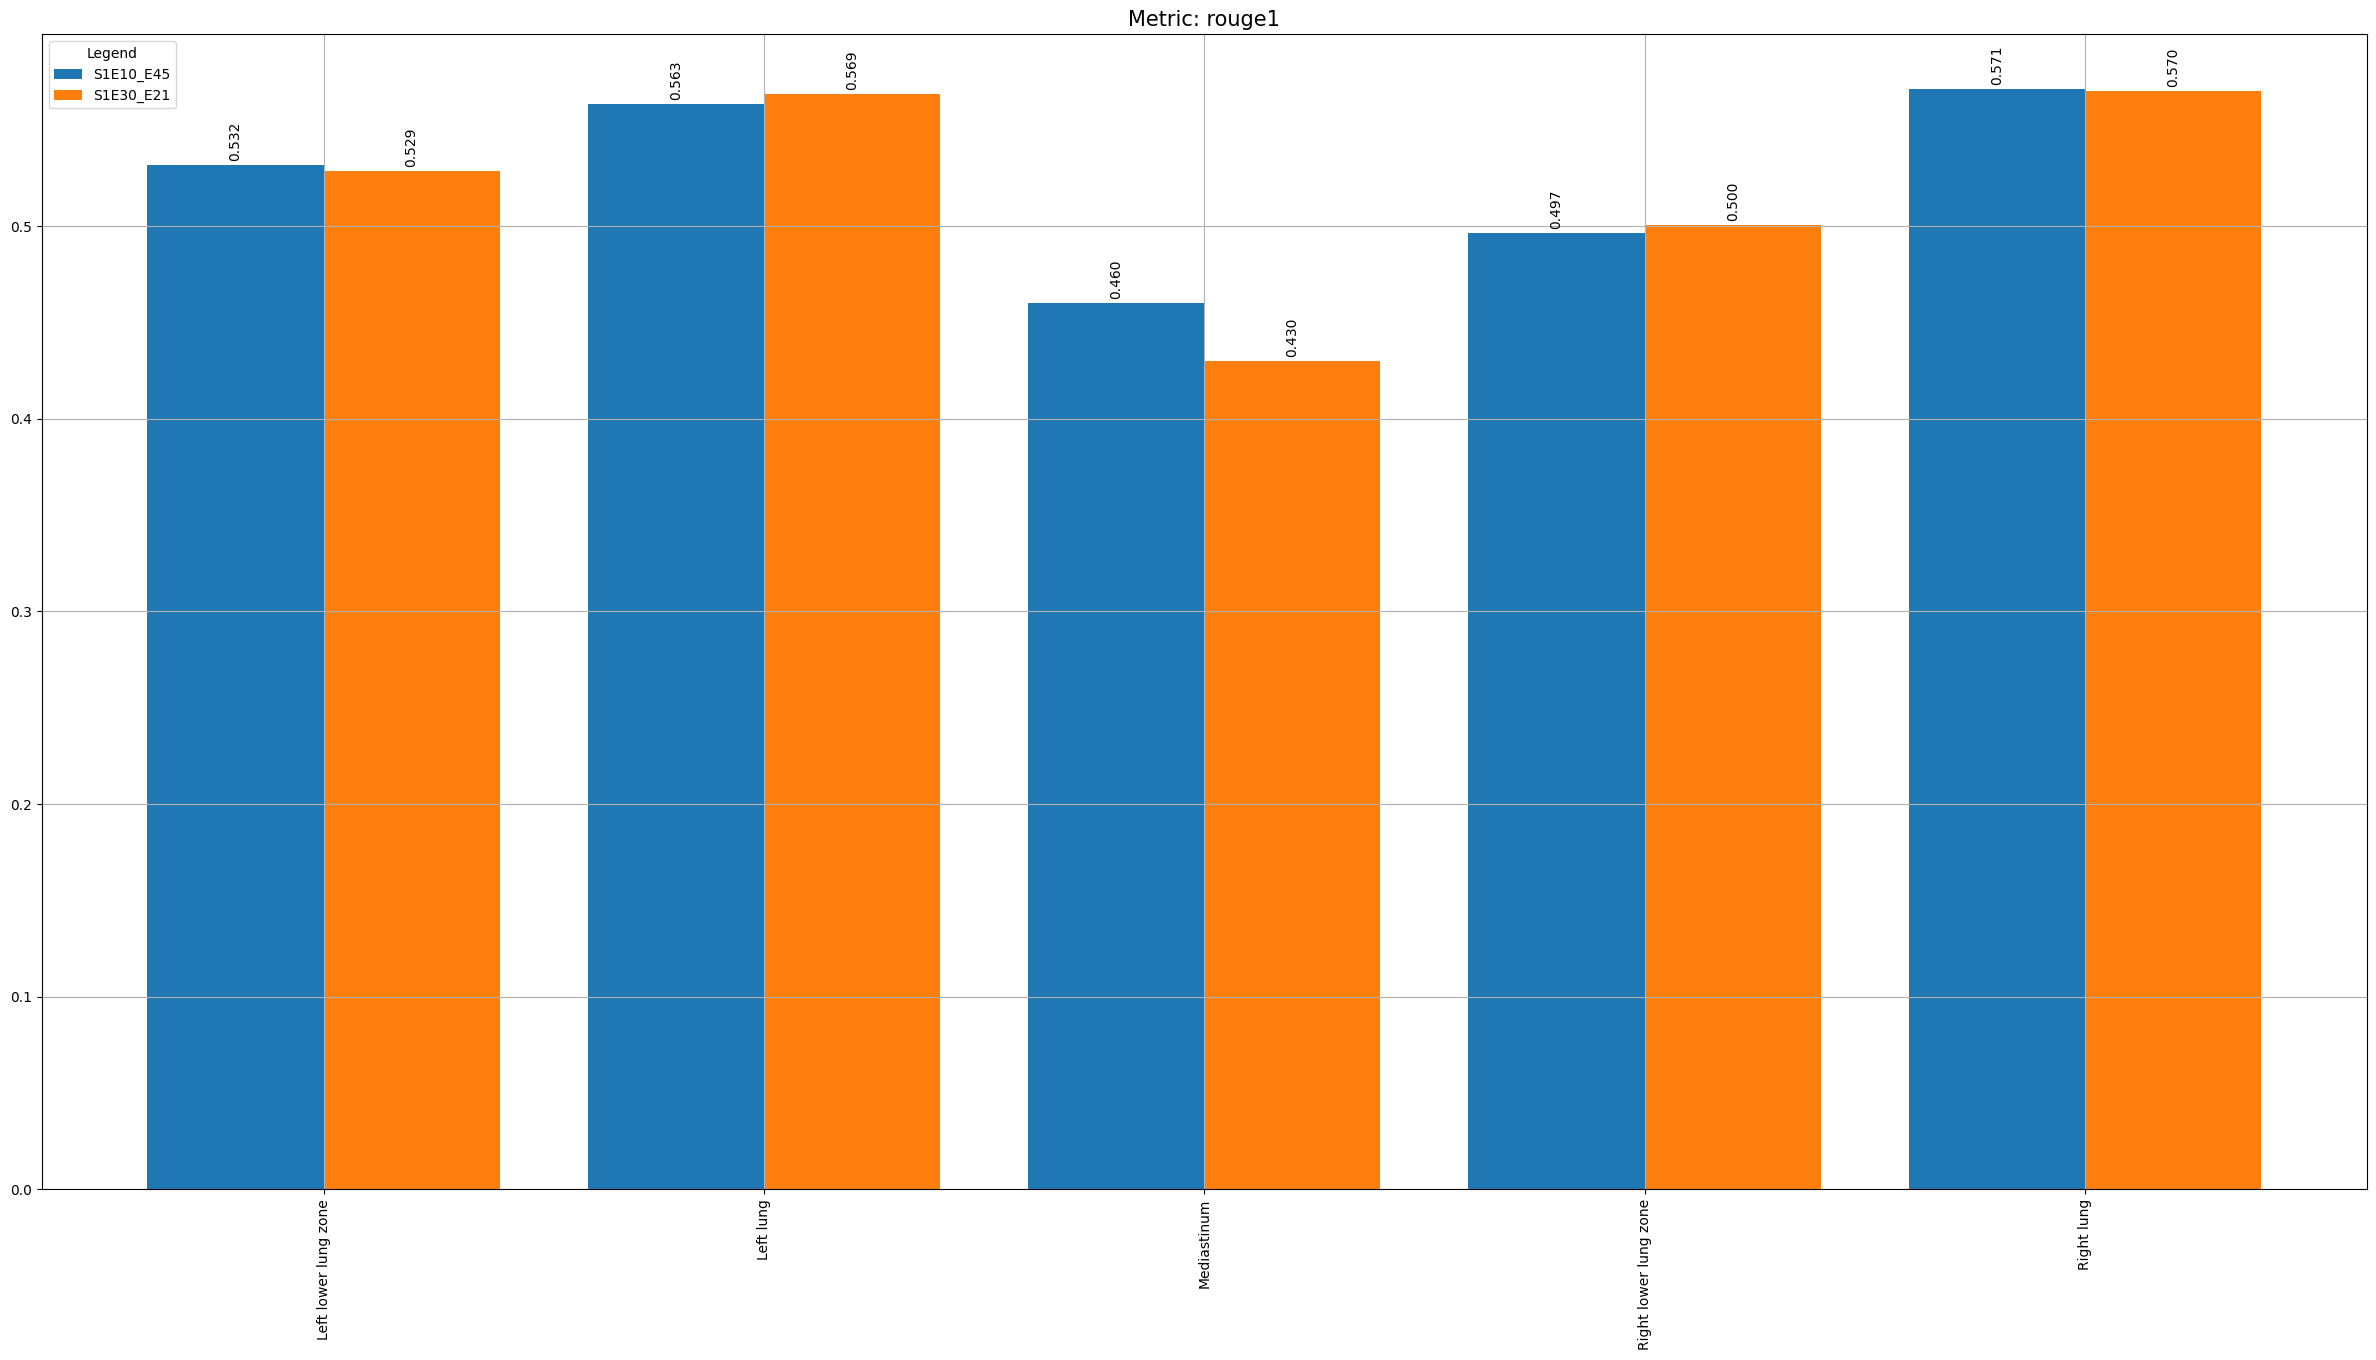

100%|██████████| 2/2 [00:00<00:00, 461.06it/s]


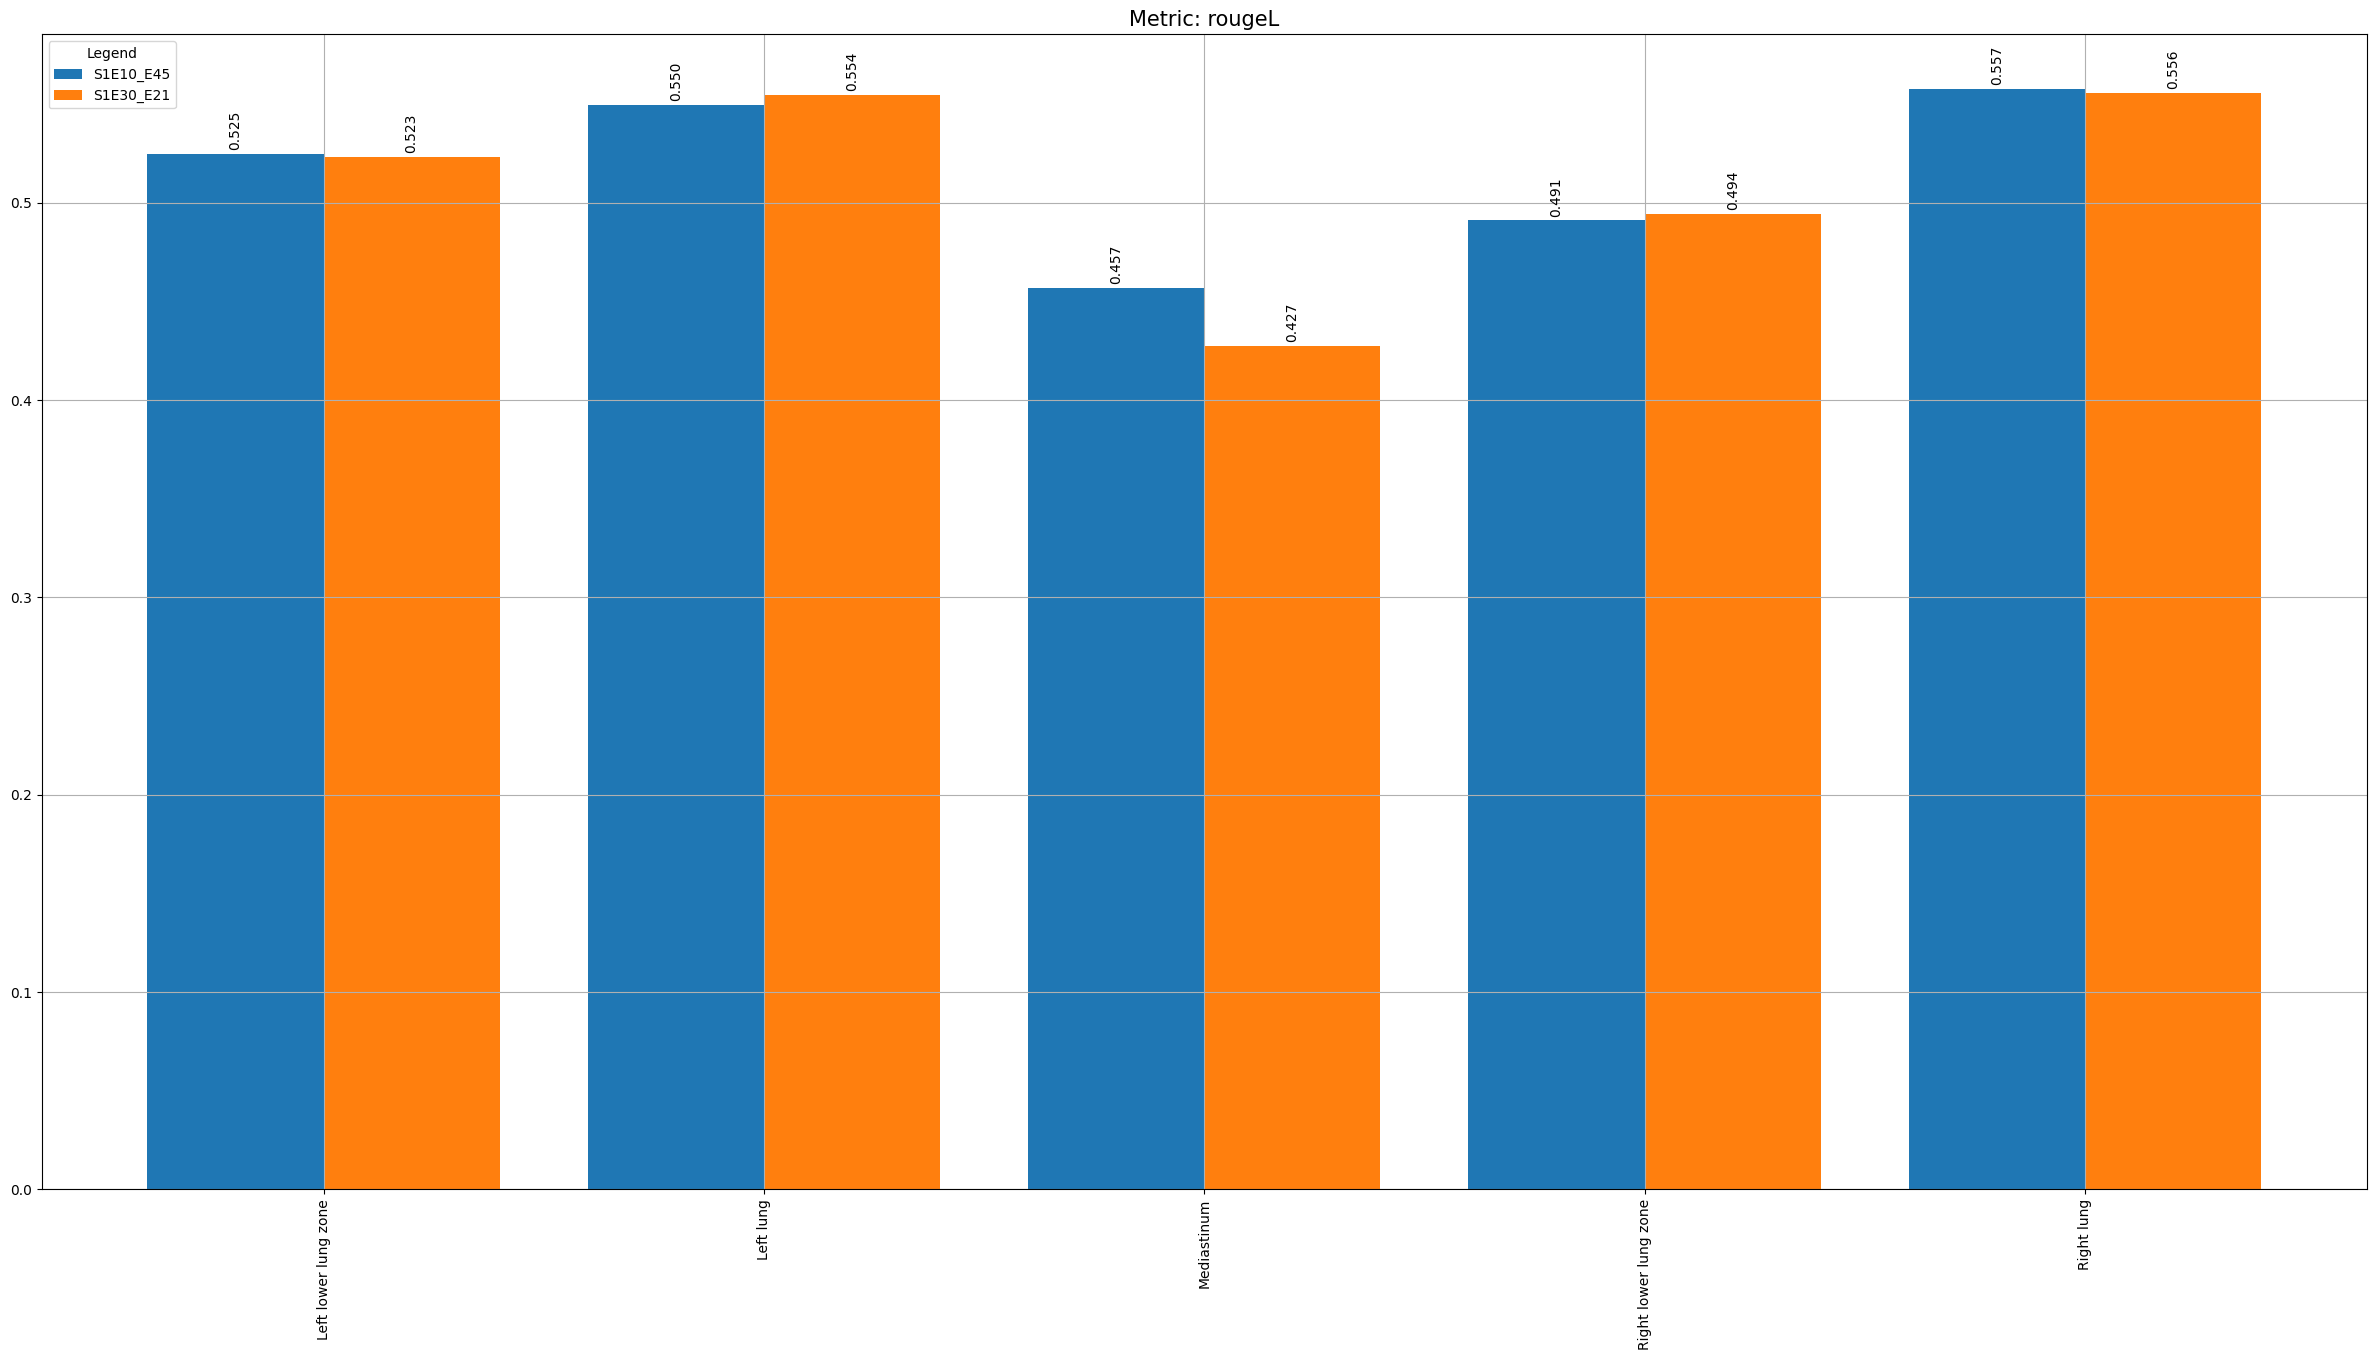

100%|██████████| 2/2 [00:00<00:00, 368.94it/s]


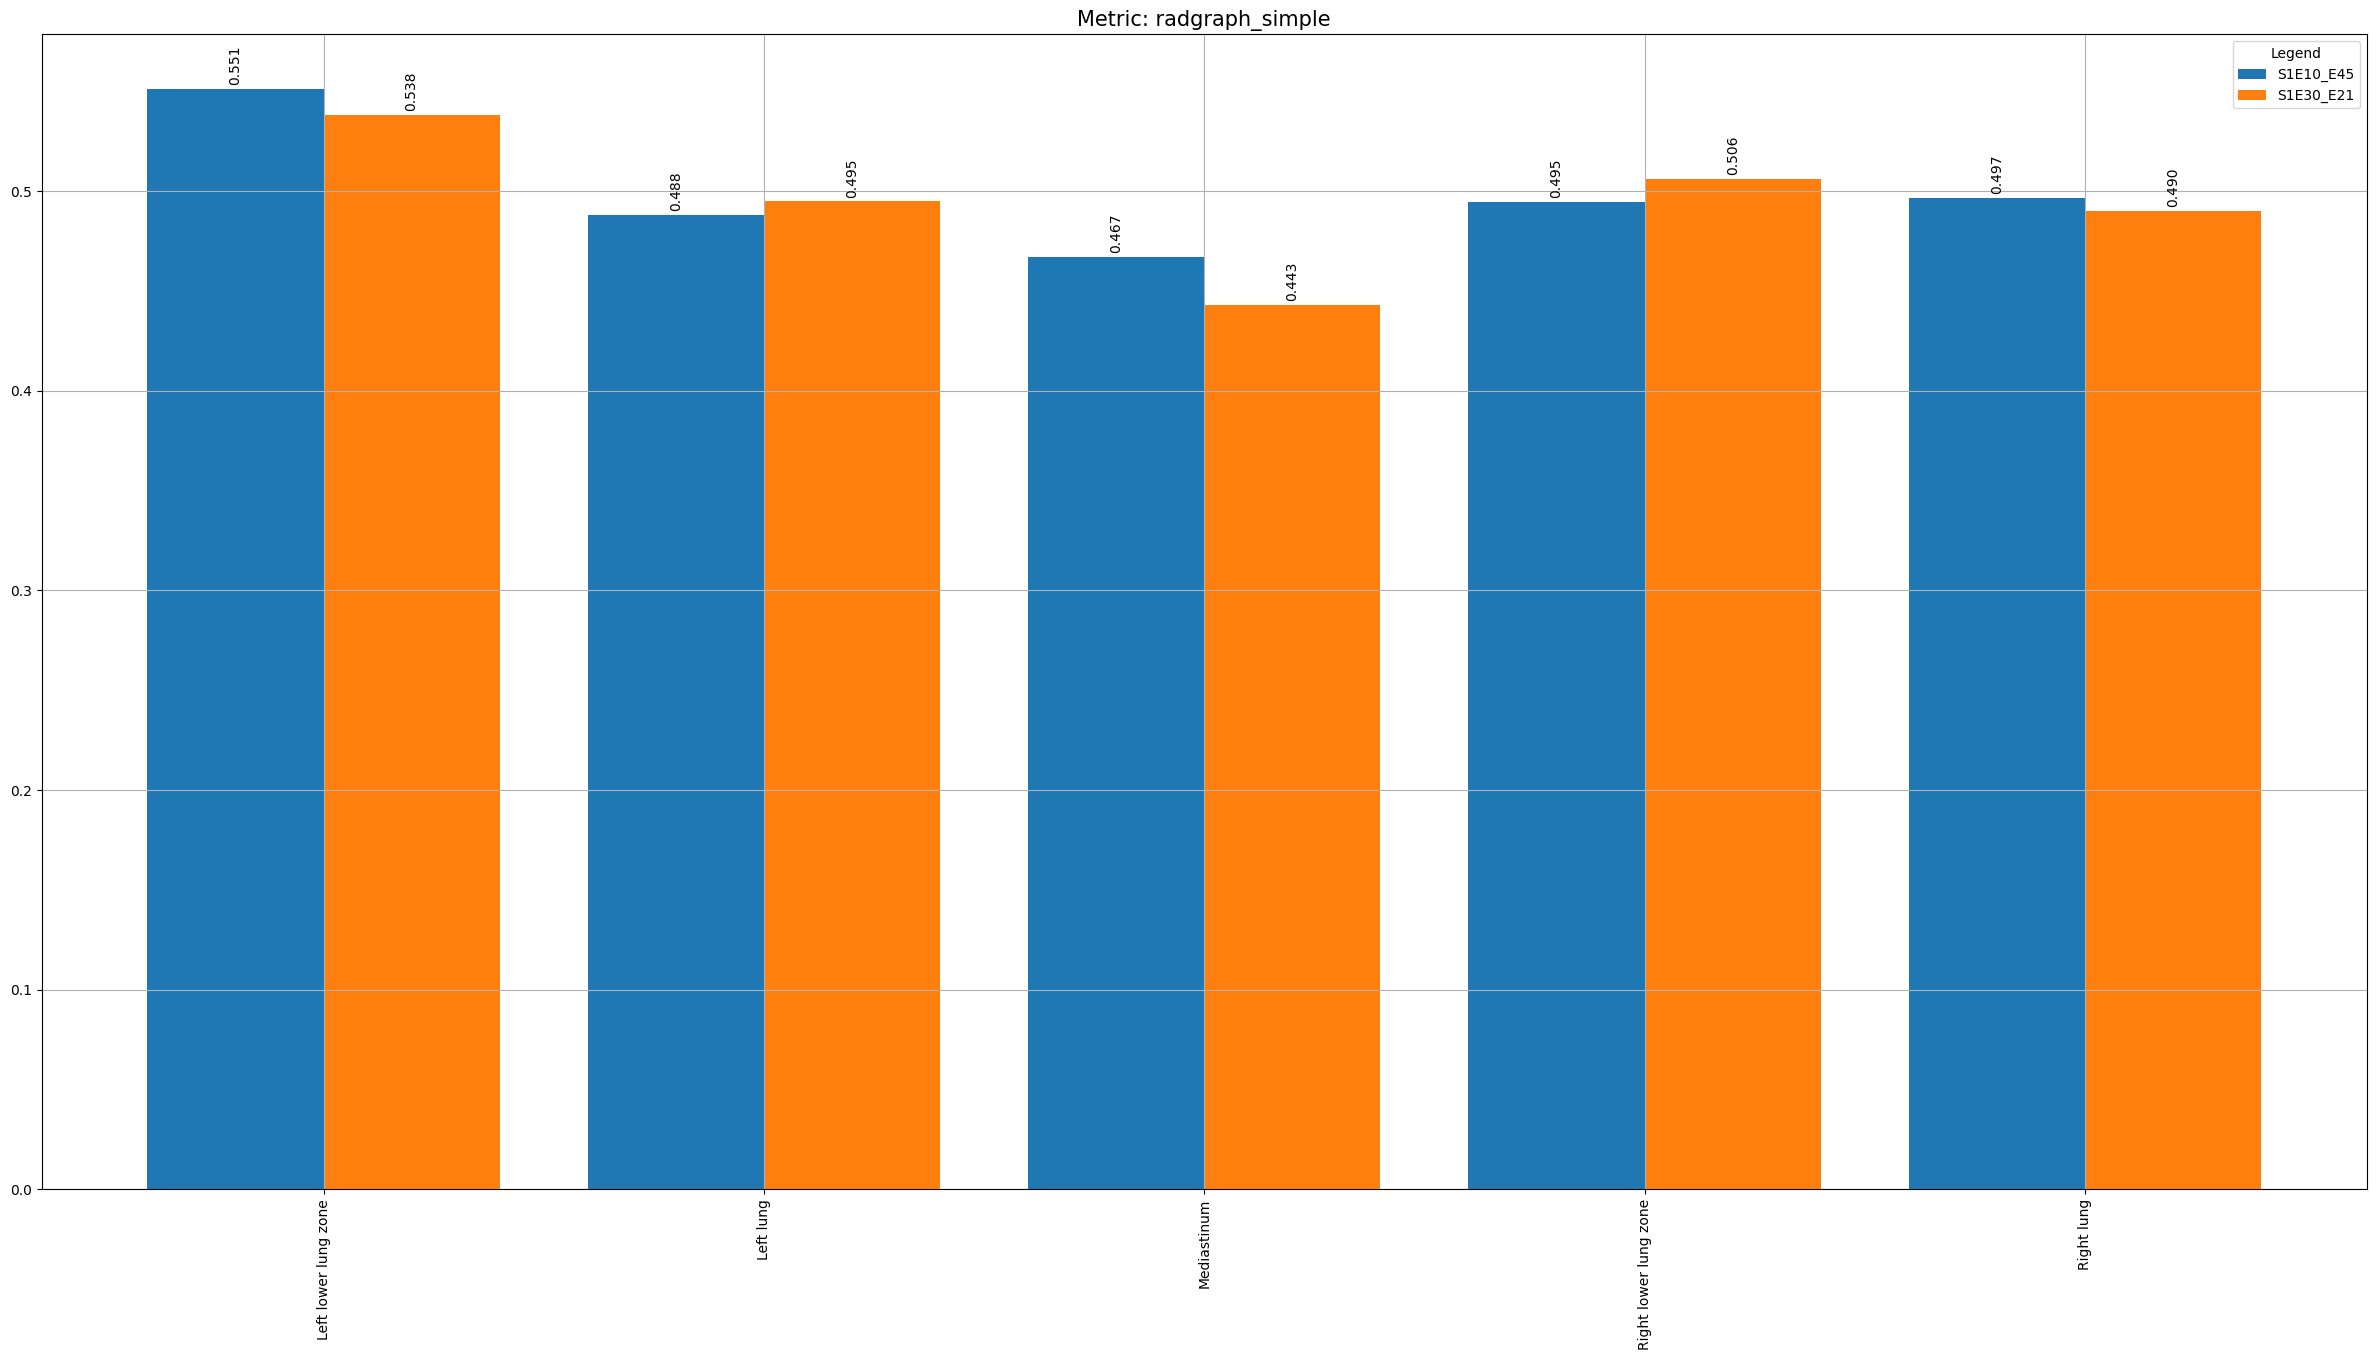

100%|██████████| 2/2 [00:00<00:00, 473.48it/s]


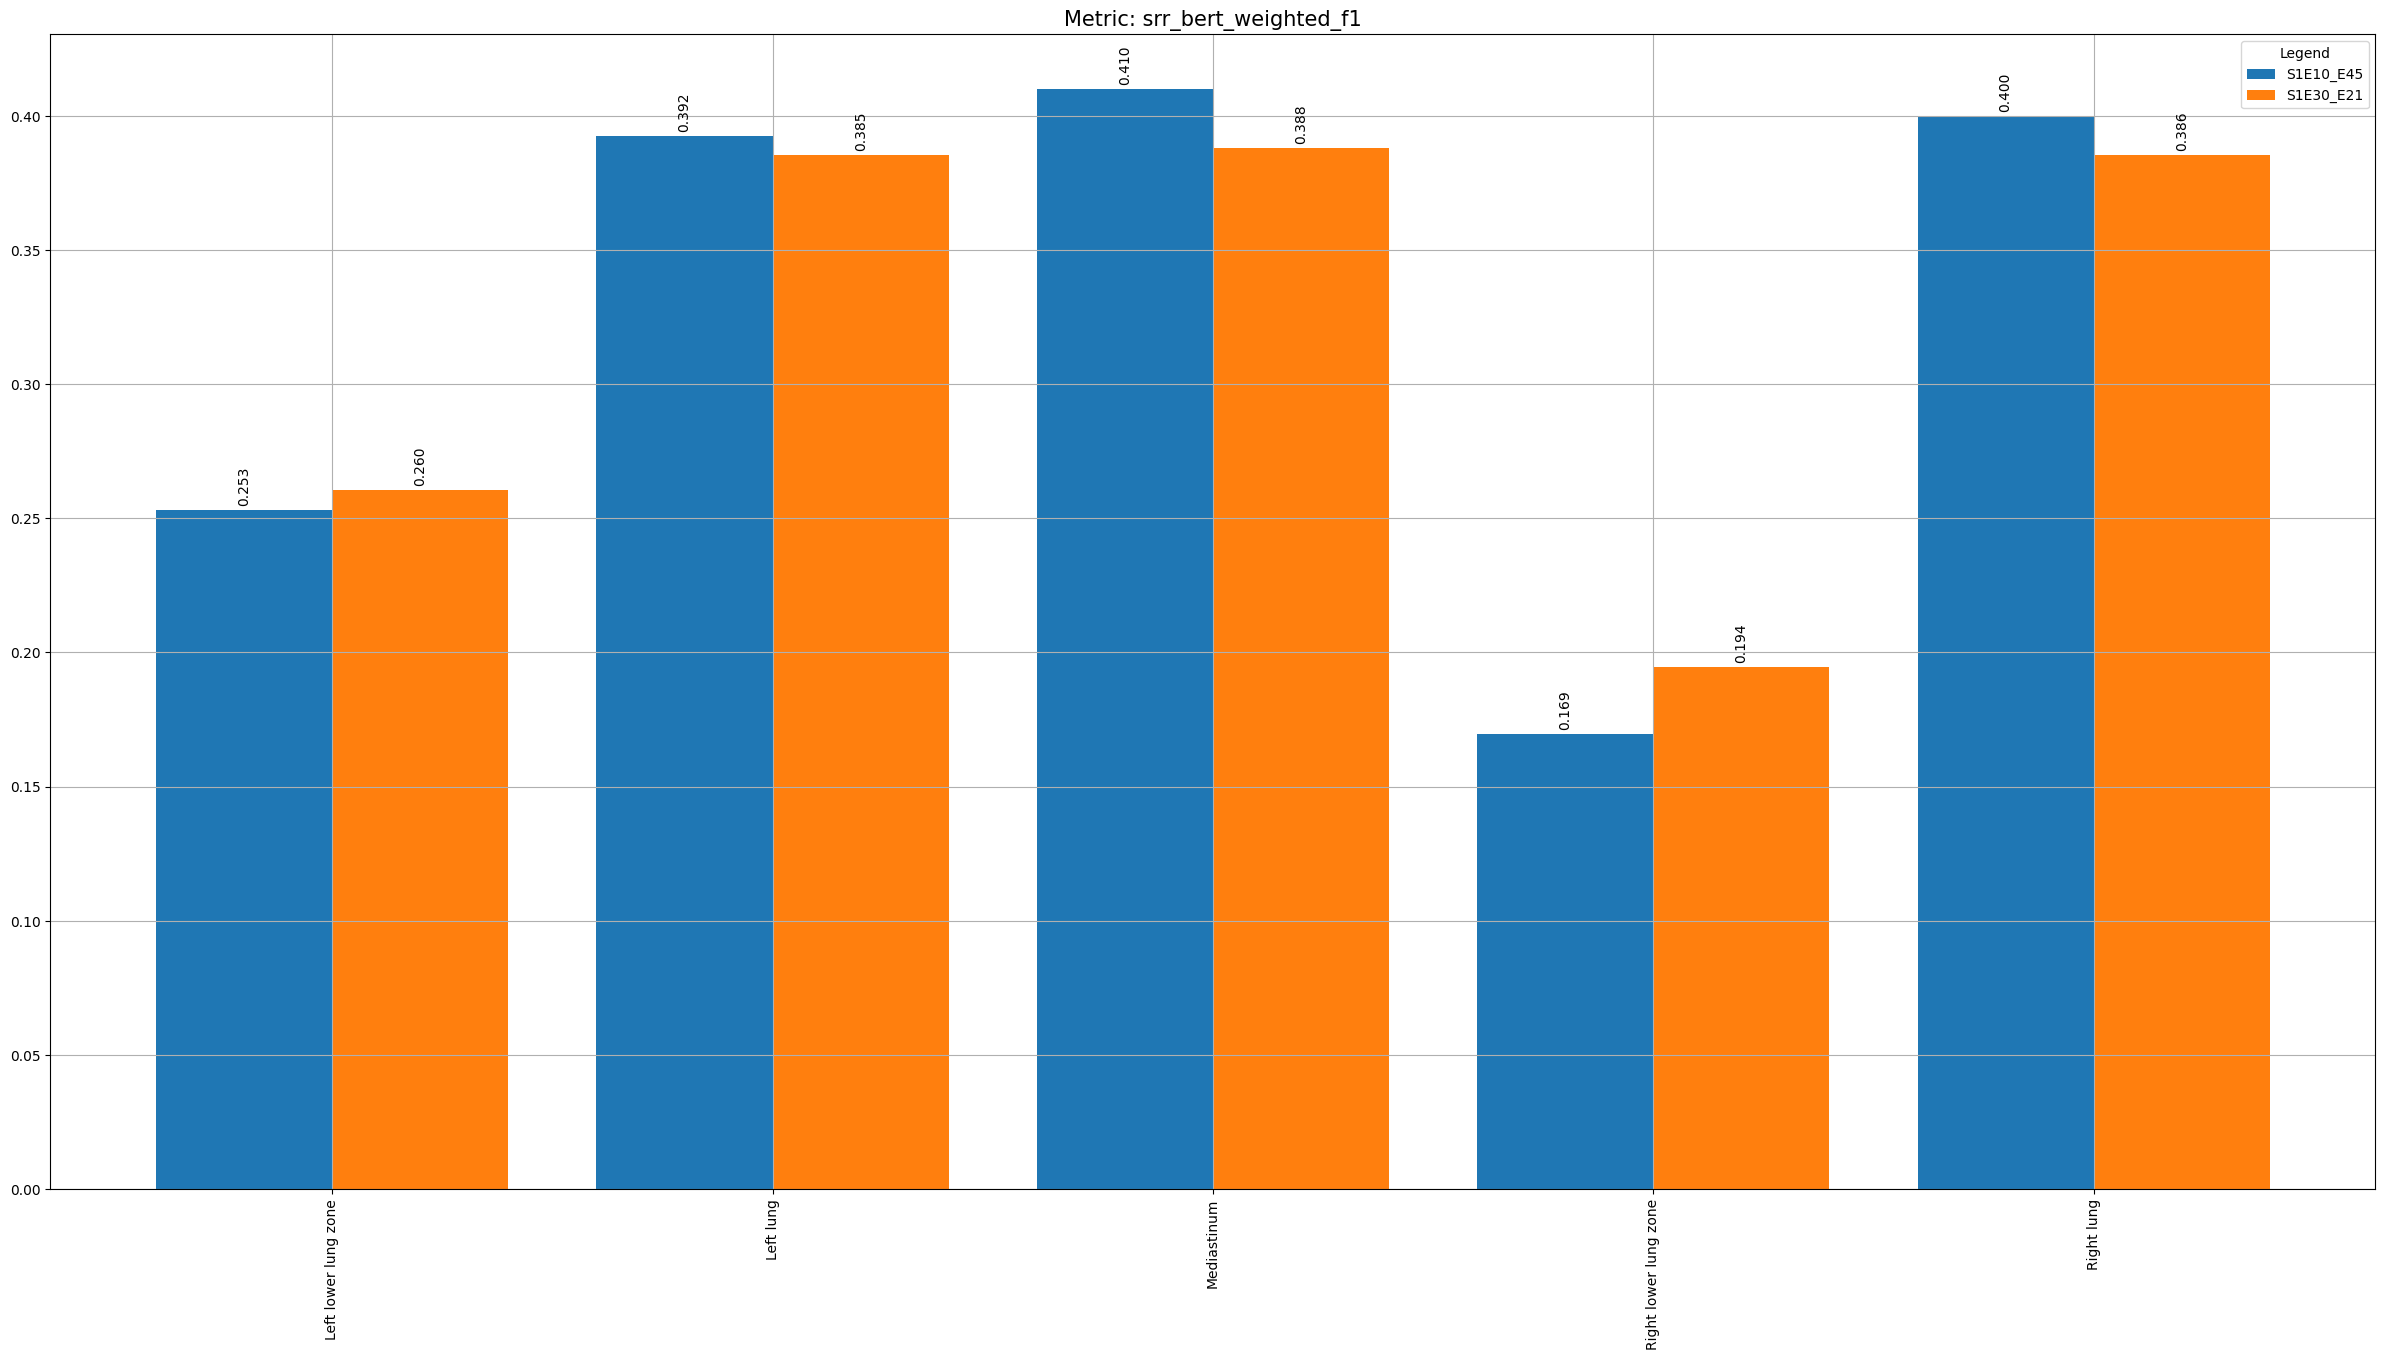

100%|██████████| 2/2 [00:00<00:00, 464.38it/s]


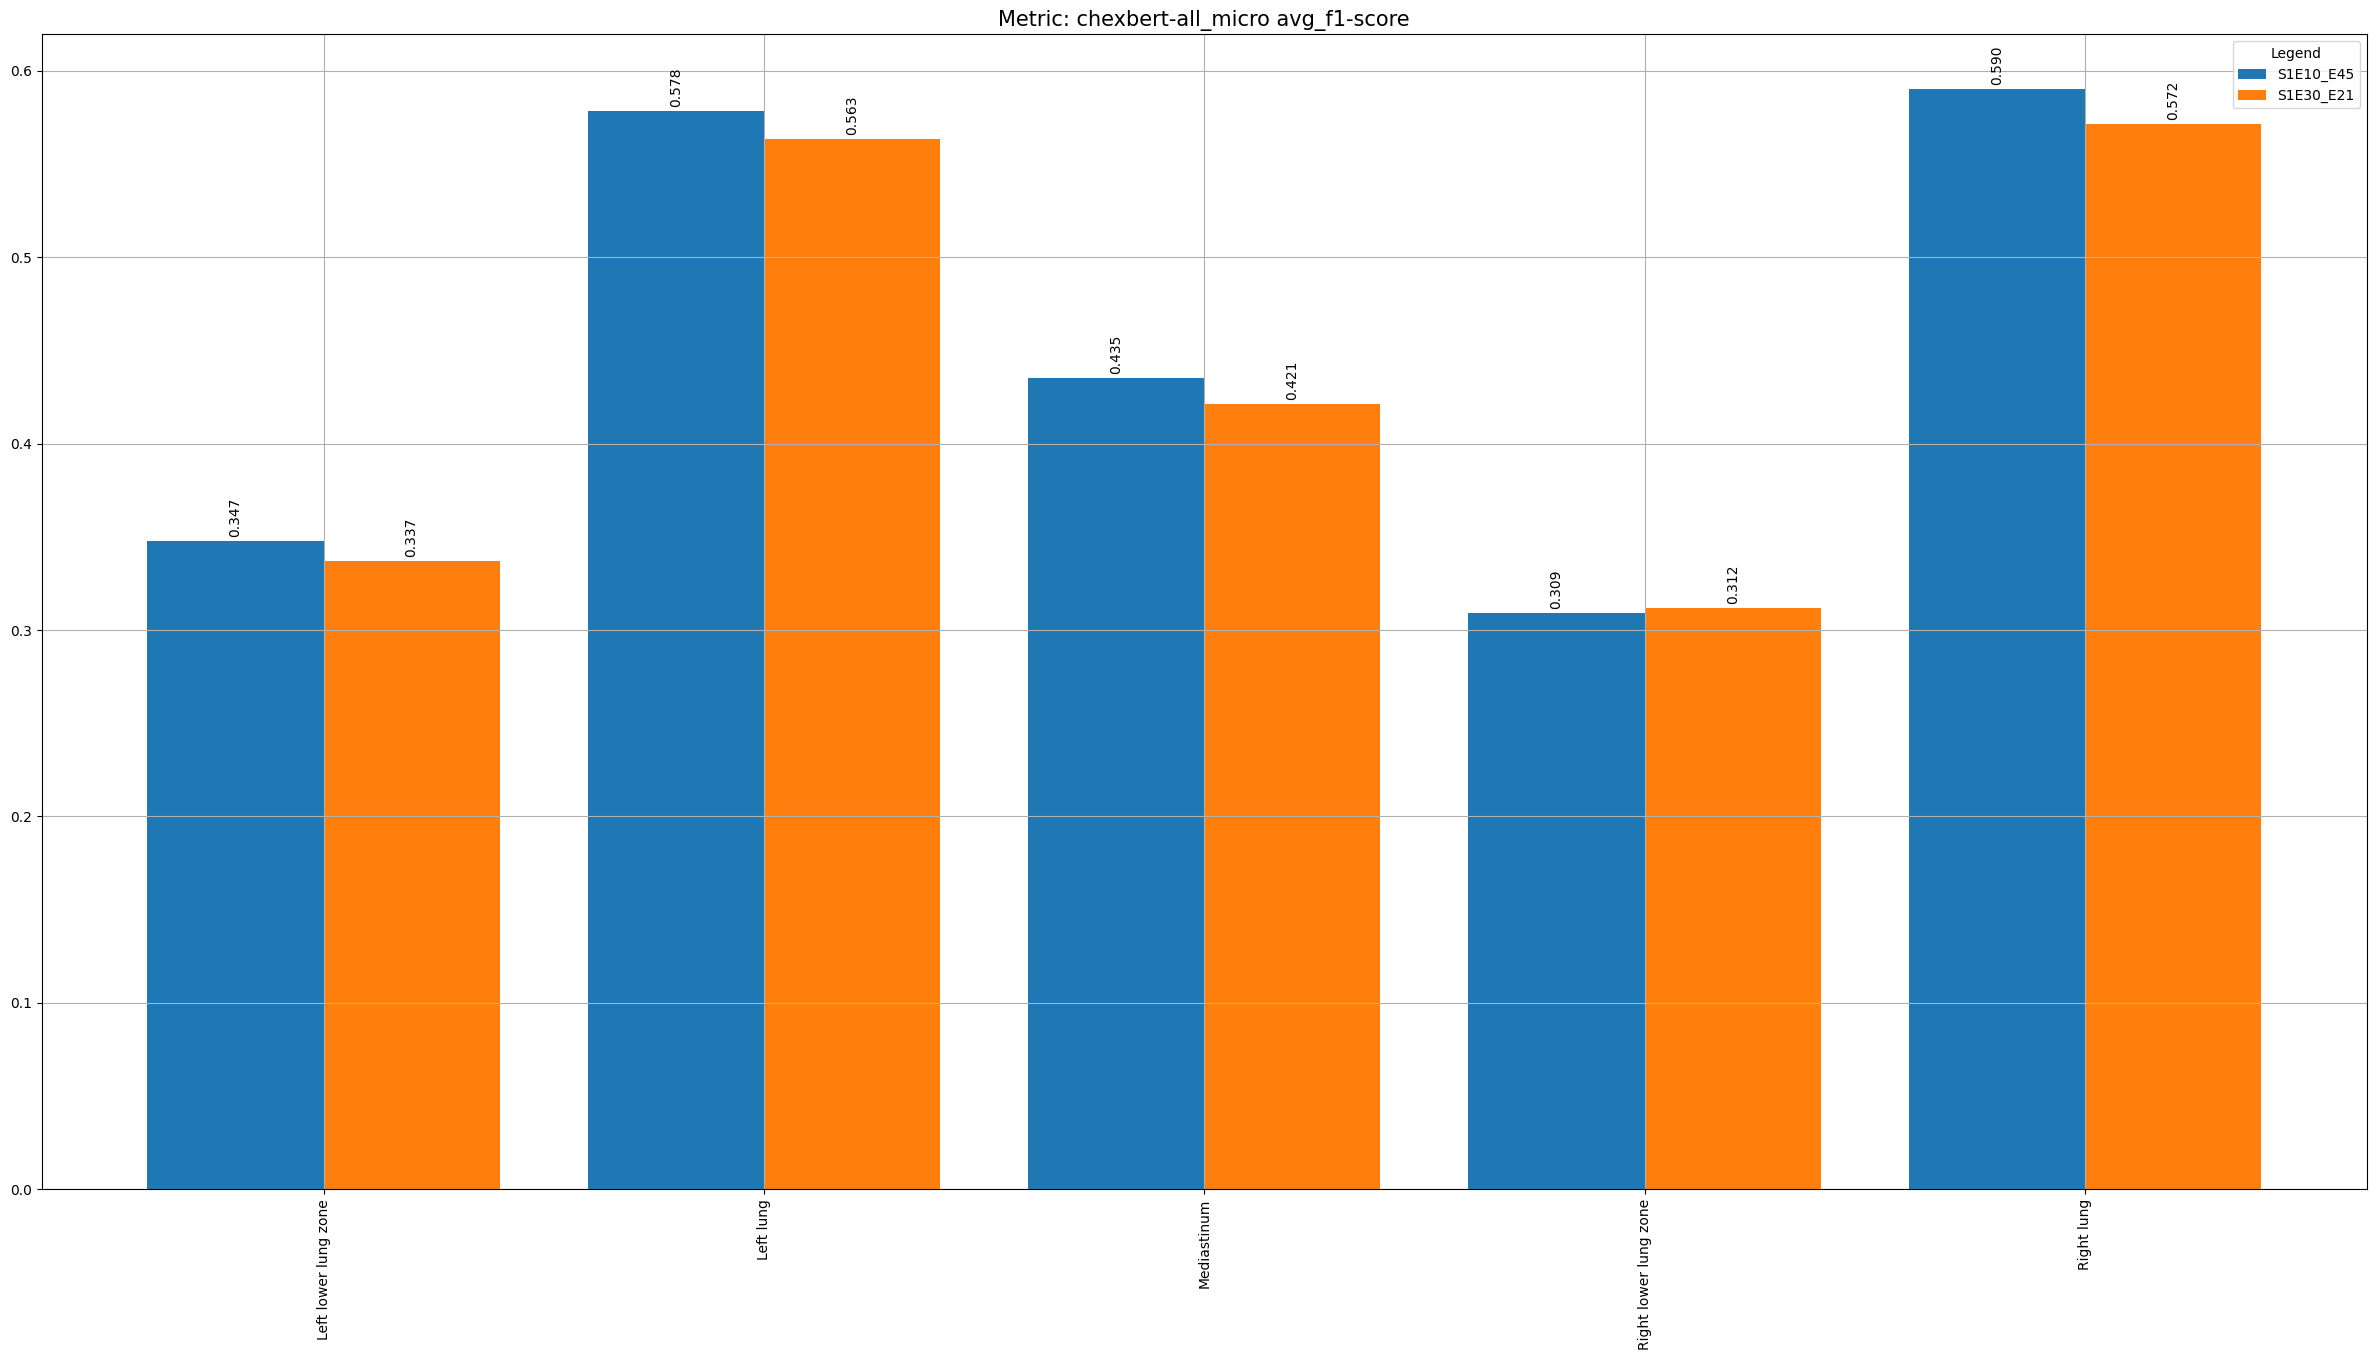

In [14]:
all_data = {}
all_epochs = False
for metricname in metrics_list:

    metrics_data = {}
    for expname in tqdm(exp_name_to_path.keys()):
        exp_path = os.path.join(exp_dir, exp_name_to_path[expname])
        exp_files = {int(i.split("_E")[-1][:-4]):i for i in os.listdir(exp_path) if i.endswith("csv") and "RAG_object_txt_metric_E" in i}
        if all_epochs:
            for epoch, epoch_file in exp_files.items():
                # print(exp_files.keys())
                # epoch = max(exp_files.keys())
                # filename = os.path.join(exp_path, exp_files[epoch])
                filename = os.path.join(exp_path, epoch_file)
                df = pd.read_csv(filename)
                df.rename(columns={"Unnamed: 0": "metric"}, inplace=True)
                df.set_index('metric', inplace=True)
                if len(set(metrics_list) & set(df.index.tolist())) != len(metrics_list):
                    print(f"Skipping: {expname}_E{epoch}")
                    continue
                metrics_data[f'{expname}_E{epoch}'] = df.loc[metricname].to_dict()
        else:
            epoch = max(exp_files.keys())
            filename = os.path.join(exp_path, exp_files[epoch])
            # filename = os.path.join(exp_path, epoch_file)
            df = pd.read_csv(filename)
            df.rename(columns={"Unnamed: 0": "metric"}, inplace=True)
            df.set_index('metric', inplace=True)
            if len(set(metrics_list) & set(df.index.tolist())) != len(metrics_list):
                print(f"Skipping: {expname}_E{epoch}")
                continue
            metrics_data[f'{expname}_E{epoch}'] = df.loc[metricname].to_dict()
    all_data[metricname] = metrics_data
    
    plot_averages_by_k2(metrics_data, excluded_objects)
    plt.grid()
    plt.title(f"Metric: {metricname}", fontsize=15)
    plt.show()
    # break

In [42]:
exclude_experiments = [i for i in all_data['accuracy'].keys() if "E7" not in i]
exclude_experiments

['S1E10_E22', 'S1E10_E29', 'S1E28_E6']

In [43]:
metricsnames = ['accuracy', "meteor", "radgraph_simple", "chexbert-all_micro avg_f1-score"]
# metricsnames = ['accuracy', "meteor", "radgraph_simple", "rougeL", "chexbert-all_micro avg_f1-score"]
get_ranks(all_data,metricsnames, top_n=5, excluded_objects=excluded_objects, exclude_experiments = exclude_experiments)


=== Ranking Results for accuracy ===
['S1E10_E7', 'S1E28_E7']


=== Ranking Results for meteor ===
['S1E10_E7', 'S1E28_E7']


=== Ranking Results for radgraph_simple ===
['S1E10_E7', 'S1E28_E7']


=== Ranking Results for chexbert-all_micro avg_f1-score ===
['S1E10_E7', 'S1E28_E7']




In [44]:
get_ranks(all_data,metricsnames, top_n=5, excluded_objects=excluded_objects, return_full=True, exclude_experiments = exclude_experiments)


=== Ranking Results for accuracy ===
          Average Rank  Mean Performance
S1E10_E7      1.166667          0.283739
S1E28_E7      1.833333          0.252553


=== Ranking Results for meteor ===
          Average Rank  Mean Performance
S1E10_E7           1.0          0.596253
S1E28_E7           2.0          0.552616


=== Ranking Results for radgraph_simple ===
          Average Rank  Mean Performance
S1E10_E7           1.0          0.554833
S1E28_E7           2.0          0.454878


=== Ranking Results for chexbert-all_micro avg_f1-score ===
          Average Rank  Mean Performance
S1E10_E7      1.083333          0.376552
S1E28_E7      1.916667          0.330054




In [ ]:
# db_path = "/path/to/data/experiments/RAG/DB/impressionv2/text_db_test.json"
# with open(db_path) as f:
#     db = json.load(f)

# for n in [2, 5, 10, 15, 20]:
#     excluded_objects = [k for k, v in db.items() if len(v) < n]
#     print(n, len(excluded_objects))

# thresh = 200
# # excluded_objects = [k for k, v in db.items() if len(v) > thresh or len(v) < 10]
# excluded_objects = [k for k, v in db.items() if len(v) < thresh]
# print(excluded_objects)
# print(thresh, len(excluded_objects))

In [194]:
top_n = 3
for metricname in ['accuracy', "meteor", "radgraph_simple", "chexbert-all_micro avg_f1-score"]:

    data = {k: {k1: v1 for k1, v1 in v.items() if k1 not in excluded_objects} for k, v in all_data[metricname].items()}


    # Convert dict → DataFrame (rows = experiments, cols = datasets)
    df = pd.DataFrame(data).T

    # --- 1. Ranking aggregation ---
    # Rank within each dataset (higher is better → so we rank -score)
    ranks = df.apply(lambda col: rankdata(-col), axis=0)
    avg_ranks = ranks.mean(axis=1)

    rank_results = pd.DataFrame({
        "Average Rank": avg_ranks,
        "Mean Performance": df.mean(axis=1)
    }).sort_values("Average Rank")
    
    print(f"=== Ranking Results for {metricname} ===")
    print(rank_results.iloc[:top_n])
    print("\n")


=== Ranking Results for accuracy ===
           Average Rank  Mean Performance
S1DE1_E4            NaN          0.401227
S1DE1_E5            NaN          0.348312
S1DE2_E11           NaN          0.390270


=== Ranking Results for meteor ===
           Average Rank  Mean Performance
S1DE1_E4            NaN          0.535912
S1DE1_E5            NaN          0.535646
S1DE2_E11           NaN          0.543651


=== Ranking Results for radgraph_simple ===
           Average Rank  Mean Performance
S1DE1_E4            NaN          0.467448
S1DE1_E5            NaN          0.449678
S1DE2_E11           NaN          0.502228


=== Ranking Results for chexbert-all_micro avg_f1-score ===
           Average Rank  Mean Performance
S1DE1_E4            NaN          0.420253
S1DE1_E5            NaN          0.368517
S1DE2_E11           NaN          0.426656




In [110]:
rank_results

,Average Rank,Mean Performance
S1E10_E29,3.315789,0.398821
S1DE2_E9,4.947368,0.415466
S1E25_E42,5.210526,0.367976
S1E19_E31,5.263158,0.373075
S1E24_E40,5.289474,0.372508
S1E23_E40,5.289474,0.372508
S1E26_E42,5.315789,0.367606
S1E27_E40,5.842105,0.371559
S1DE3_E13,6.684211,0.367728
S1E28_E6,7.842105,0.348141


In [17]:
# data = {}
# metricname = 'accuracy'
# for expname in tqdm(exp_name_to_path.keys()):
#     exp_path = os.path.join(exp_dir, exp_name_to_path[expname])
#     exp_files = {int(i.split("_E")[-1][:-4]):i for i in os.listdir(exp_path) if i.endswith("csv") and "RAG_object_txt_metric_E" in i}
#     epoch = max(exp_files.keys())
#     print(expname, epoch)
#     filename = os.path.join(exp_path, exp_files[epoch])
#     df = pd.read_csv(filename)
#     df.rename(columns={"Unnamed: 0": "metric"}, inplace=True)
#     df.set_index('metric', inplace=True)
#     data[f'{expname}_E{epoch}'] = df.loc[metricname].to_dict()

# plot_averages_by_k2(data)
# plt.title(f"{metricname} Metric")

In [18]:

# data = {}
# metricname = "chexbert-all_micro avg_f1-score"
# for expname in tqdm(exp_name_to_path.keys()):
#     exp_path = os.path.join(exp_dir, exp_name_to_path[expname])
#     exp_files = {int(i.split("_E")[-1][:-4]):i for i in os.listdir(exp_path) if i.endswith("csv") and "RAG_object_txt_metric_E" in i}
#     epoch = max(exp_files.keys())
#     print(expname, epoch)
#     filename = os.path.join(exp_path, exp_files[epoch])
#     df = pd.read_csv(filename)
#     df.rename(columns={"Unnamed: 0": "metric"}, inplace=True)
#     df.set_index('metric', inplace=True)
#     data[f'{expname}_E{epoch}'] = df.loc[metricname].to_dict()

# plot_averages_by_k2(data)
# plt.title(f"{metricname} Metric")